<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/hw6_CSCI4170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Reinforcement Learning with Value Iteration in a Small Grid World

This part implements value iteration for a small discrete **Markov Decision Process (MDP)** using a simple grid world environment.

The goal is to:
- define the state space, action space, reward structure, and discount factor
- compute the optimal value function
- extract the final policy
- display the value function and policy clearly
- compare how the policy changes when the discount factor changes

A grid world is a good example of an MDP because the agent is always in one discrete state, takes one action at a time, receives a reward, and transitions to a new state based only on the current state and action.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

## Defining the grid world

We will use a small 4x4 grid. The agent starts somewhere in the grid and can move:
- up
- down
- left
- right

Some cells have special meaning:
- one goal state with a positive reward
- one pit state with a negative reward
- one wall that cannot be entered

The agent also receives a small step penalty each time it moves, which encourages it to find shorter paths.

In [2]:
# Grid setup
ROWS, COLS = 4, 4

# Special cells
GOAL = (0, 3)
PIT = (1, 3)
WALL = (1, 1)

# Rewards
GOAL_REWARD = 10.0
PIT_REWARD = -10.0
STEP_REWARD = -0.1

# Discount factor
gamma = 0.9

# Actions
actions = ['U', 'D', 'L', 'R']
action_moves = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}

## State space and action space

Each valid grid cell is a state, except the wall, which is excluded from the state space.

The action space is the same for all non-terminal states:
- Up
- Down
- Left
- Right

The goal and pit will be treated as terminal states, meaning the episode ends once the agent reaches them.

In [3]:
def is_valid_cell(r, c):
    return 0 <= r < ROWS and 0 <= c < COLS and (r, c) != WALL

states = [(r, c) for r in range(ROWS) for c in range(COLS) if is_valid_cell(r, c)]
terminal_states = [GOAL, PIT]

print("States:")
print(states)

print("\nTerminal states:")
print(terminal_states)

print("\nActions:")
print(actions)

States:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]

Terminal states:
[(0, 3), (1, 3)]

Actions:
['U', 'D', 'L', 'R']


## Transition and reward function

This environment is deterministic:
- the chosen action directly determines the next state
- if the move would go out of bounds or into the wall, the agent stays in place

Rewards are defined as follows:
- reaching the goal gives a large positive reward
- reaching the pit gives a large negative reward
- every normal move gives a small negative step reward

In [4]:
def next_state_reward(state, action):
    """
    Given a state and action, return (next_state, reward).
    This environment is deterministic.
    """
    if state in terminal_states:
        return state, 0.0

    r, c = state
    dr, dc = action_moves[action]
    nr, nc = r + dr, c + dc

    if not is_valid_cell(nr, nc):
        nr, nc = r, c

    new_state = (nr, nc)

    if new_state == GOAL:
        reward = GOAL_REWARD
    elif new_state == PIT:
        reward = PIT_REWARD
    else:
        reward = STEP_REWARD

    return new_state, reward

## Implementing value iteration

Value iteration repeatedly updates the value of each state using the Bellman optimality equation:

V(s) = max over actions a of the sum over next states s' of:

P(s' | s, a) * [ R(s, a, s') + gamma * V(s') ]

Because this grid world is deterministic, each action leads to exactly one next state. After the values converge, the optimal policy can be extracted by choosing the action with the highest one-step return from each state.

In [5]:
def value_iteration(states, actions, gamma=0.9, theta=1e-6, max_iterations=1000):
    V = {s: 0.0 for s in states}

    for iteration in range(max_iterations):
        delta = 0.0
        new_V = V.copy()

        for s in states:
            if s in terminal_states:
                new_V[s] = 0.0
                continue

            action_values = []
            for a in actions:
                s_next, r = next_state_reward(s, a)
                action_value = r + gamma * V[s_next]
                action_values.append(action_value)

            best_value = max(action_values)
            delta = max(delta, abs(best_value - V[s]))
            new_V[s] = best_value

        V = new_V

        if delta < theta:
            print(f"Value iteration converged in {iteration + 1} iterations.")
            break

    return V

## Extracting the final policy

Once the value function is learned, the policy is found by selecting the action that gives the highest expected return from each state.

This tells us what the agent should do in each location if it wants to maximize long-term reward.

In [6]:
def extract_policy(V, states, actions, gamma=0.9):
    policy = {}

    for s in states:
        if s in terminal_states:
            policy[s] = 'T'
            continue

        best_action = None
        best_value = -float('inf')

        for a in actions:
            s_next, r = next_state_reward(s, a)
            action_value = r + gamma * V[s_next]

            if action_value > best_value:
                best_value = action_value
                best_action = a

        policy[s] = best_action

    return policy

## Running value iteration

Now we compute the learned value function and optimal policy for the grid world.

In [7]:
V = value_iteration(states, actions, gamma=gamma)
policy = extract_policy(V, states, actions, gamma=gamma)

print("Learned Value Function:")
pprint(V)

print("\nFinal Policy:")
pprint(policy)

Value iteration converged in 7 iterations.
Learned Value Function:
{(0, 0): 7.91,
 (0, 1): 8.9,
 (0, 2): 10.0,
 (0, 3): 0.0,
 (1, 0): 7.019000000000001,
 (1, 2): 8.9,
 (1, 3): 0.0,
 (2, 0): 6.217100000000001,
 (2, 1): 7.019000000000001,
 (2, 2): 7.91,
 (2, 3): 7.019000000000001,
 (3, 0): 5.495390000000001,
 (3, 1): 6.217100000000001,
 (3, 2): 7.019000000000001,
 (3, 3): 6.217100000000001}

Final Policy:
{(0, 0): 'R',
 (0, 1): 'R',
 (0, 2): 'R',
 (0, 3): 'T',
 (1, 0): 'U',
 (1, 2): 'U',
 (1, 3): 'T',
 (2, 0): 'U',
 (2, 1): 'R',
 (2, 2): 'U',
 (2, 3): 'L',
 (3, 0): 'U',
 (3, 1): 'U',
 (3, 2): 'U',
 (3, 3): 'U'}


## Displaying the value function and policy in readable form

The value function shows how good each state is under the optimal strategy.

The policy grid shows which direction the agent chooses in each state:
- U = up
- D = down
- L = left
- R = right
- T = terminal
- W = wall

In [8]:
def print_value_grid(V):
    grid = np.full((ROWS, COLS), np.nan)
    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) == WALL:
                continue
            grid[r, c] = V[(r, c)]
    print(np.round(grid, 2))

def print_policy_grid(policy):
    grid = np.full((ROWS, COLS), '', dtype=object)
    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) == WALL:
                grid[r, c] = 'W'
            else:
                grid[r, c] = policy[(r, c)]
    print(grid)

print("Value Function Grid:")
print_value_grid(V)

print("\nPolicy Grid:")
print_policy_grid(policy)

Value Function Grid:
[[ 7.91  8.9  10.    0.  ]
 [ 7.02   nan  8.9   0.  ]
 [ 6.22  7.02  7.91  7.02]
 [ 5.5   6.22  7.02  6.22]]

Policy Grid:
[['R' 'R' 'R' 'T']
 ['U' 'W' 'U' 'T']
 ['U' 'R' 'U' 'L']
 ['U' 'U' 'U' 'U']]


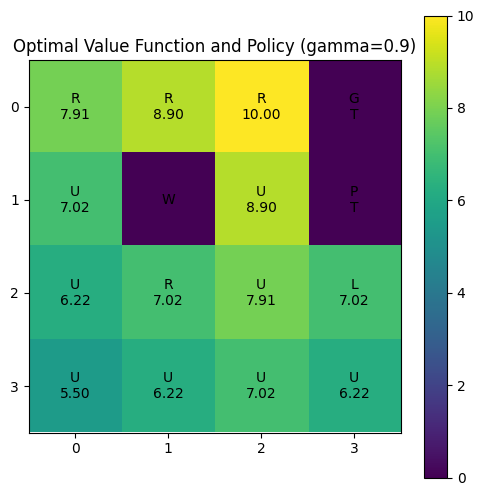

In [9]:
def plot_value_and_policy(V, policy, title="Grid World"):
    fig, ax = plt.subplots(figsize=(6, 6))

    value_grid = np.zeros((ROWS, COLS))
    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) == WALL:
                value_grid[r, c] = 0
            else:
                value_grid[r, c] = V[(r, c)]

    im = ax.imshow(value_grid)

    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) == WALL:
                text = "W"
            elif (r, c) == GOAL:
                text = "G\nT"
            elif (r, c) == PIT:
                text = "P\nT"
            else:
                text = f"{policy[(r,c)]}\n{V[(r,c)]:.2f}"
            ax.text(c, r, text, ha='center', va='center', fontsize=10)

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.show()

plot_value_and_policy(V, policy, title=f"Optimal Value Function and Policy (gamma={gamma})")

## Small experiment: changing the discount factor

A useful experiment is to vary the discount factor \(\gamma\), which controls how much the agent values future rewards.

- A **smaller** discount factor makes the agent more short-sighted
- A **larger** discount factor makes the agent care more about long-term outcomes

We will compare policies for two different discount factors.

In [10]:
gammas = [0.5, 0.9]
results = {}

for g in gammas:
    V_g = value_iteration(states, actions, gamma=g)
    policy_g = extract_policy(V_g, states, actions, gamma=g)
    results[g] = (V_g, policy_g)

Value iteration converged in 7 iterations.
Value iteration converged in 7 iterations.


In [11]:
for g in gammas:
    print(f"\n===== Results for gamma = {g} =====")
    print("Value Function Grid:")
    print_value_grid(results[g][0])
    print("\nPolicy Grid:")
    print_policy_grid(results[g][1])


===== Results for gamma = 0.5 =====
Value Function Grid:
[[ 2.35  4.9  10.    0.  ]
 [ 1.08   nan  4.9   0.  ]
 [ 0.44  1.08  2.35  1.08]
 [ 0.12  0.44  1.08  0.44]]

Policy Grid:
[['R' 'R' 'R' 'T']
 ['U' 'W' 'U' 'T']
 ['U' 'R' 'U' 'L']
 ['U' 'U' 'U' 'U']]

===== Results for gamma = 0.9 =====
Value Function Grid:
[[ 7.91  8.9  10.    0.  ]
 [ 7.02   nan  8.9   0.  ]
 [ 6.22  7.02  7.91  7.02]
 [ 5.5   6.22  7.02  6.22]]

Policy Grid:
[['R' 'R' 'R' 'T']
 ['U' 'W' 'U' 'T']
 ['U' 'R' 'U' 'L']
 ['U' 'U' 'U' 'U']]


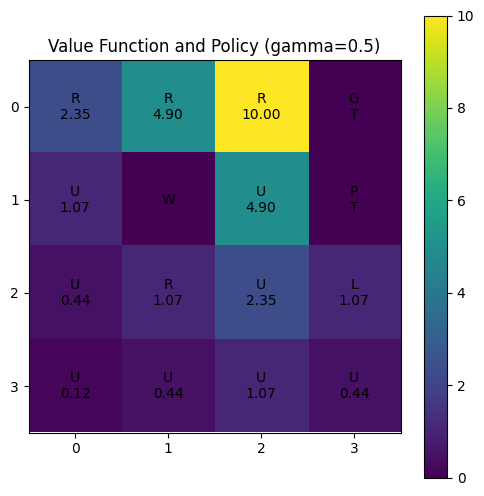

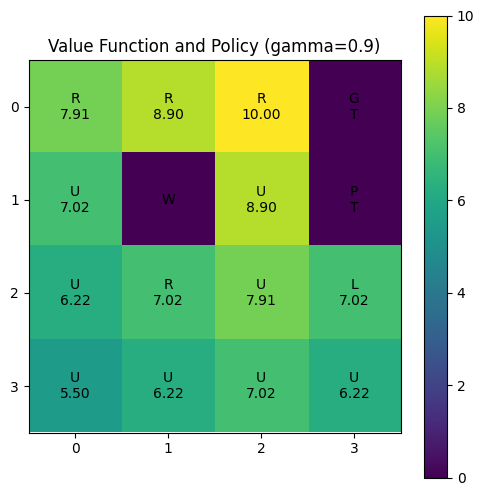

In [12]:
for g in gammas:
    plot_value_and_policy(results[g][0], results[g][1], title=f"Value Function and Policy (gamma={g})")

## Discussion

Value iteration successfully learned an optimal policy for the 4x4 grid world and converged in 7 iterations for the main setting with gamma = 0.9. The final policy consistently moves the agent toward the goal, avoids the pit, and routes around the wall. The highest state values appeared near the goal, while lower values appeared farther away due to the step penalty and longer path length. In the comparison experiment, changing the discount factor from 0.5 to 0.9 did not change the policy, but it did increase the value of nearly every non-terminal state. This shows that the agent’s preferred path stayed the same, while its estimate of long-term reward became much larger when future rewards were weighted more heavily.

# Task 2: Graph Neural Networks (GNN) for Node Classification

I chose to explore **Graph Neural Networks (GNNs)** through one focused example: **node classification** on the **Cora citation dataset**.

The main idea is to compare:
- a **Graph Convolutional Network (GCN)**, which uses both node features and graph structure
- a simple **MLP baseline**, which uses only node features and ignores the graph edges


## Graph data and node classification

A graph is a data structure made of:
- **nodes**, which represent objects
- **edges**, which represent relationships between those objects

In the Cora dataset:
- each node is a research paper
- each edge is a citation link between papers
- each paper has a feature vector
- each paper also has a class label

The task at hand here is node classification, which means predicting the class of each node using the available graph information.

## GCNs and the training objective

A Graph Convolutional Network (GCN) is a type of graph neural network that updates each node representation by combining:
- its own features
- information from neighboring nodes

This process allows the model to use local graph structure during learning.

In this notebook, the GCN outputs class scores for each node, and the model is trained using cross-entropy loss on the labeled training nodes. Since only part of the graph is labeled for training, this is a semi-supervised node classification setting.

## Sources

Primary source:
- Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks.*

Technical implementation source:
- PyTorch Geometric documentation for the Planetoid datasets and GCN layers.
https://pytorch-geometric.readthedocs.io/en/stable/generated/torch_geometric.datasets.Planetoid.html

In [2]:
!pip -q install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.5 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Loading the Cora dataset

The Cora dataset is a standard citation-network benchmark used in graph learning. After loading it, we will inspect its size and basic structure.

In [4]:
dataset = Planetoid(root="/tmp/Cora", name="Cora")
data = dataset[0].to(device)

print(f"Dataset: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of node features: {dataset.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")

print("\nMask sizes:")
print(f"Training nodes: {int(data.train_mask.sum())}")
print(f"Validation nodes: {int(data.val_mask.sum())}")
print(f"Test nodes: {int(data.test_mask.sum())}")

Processing...
Done!


Dataset: Cora()
Number of graphs: 1
Number of nodes: 2708
Number of edges: 10556
Number of node features: 1433
Number of classes: 7

Mask sizes:
Training nodes: 140
Validation nodes: 500
Test nodes: 1000


## Defining the models

The first model is a 2-layer GCN. It uses the graph edges during message passing.

The second model is a simple MLP baseline. It only uses the node feature vectors and ignores the graph edges completely.

Comparing these two models helps isolate the effect of using graph structure.

In [5]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x

## Training setup

Both models will be trained with the same optimizer and number of epochs. The main difference is that the GCN uses the graph edges, while the MLP does not.

We will track:
- training loss
- training accuracy
- validation accuracy
- test accuracy

In [6]:
def accuracy(logits, y, mask):
    preds = logits.argmax(dim=1)
    correct = (preds[mask] == y[mask]).sum().item()
    total = int(mask.sum())
    return correct / total


def train_gcn(model, data, epochs=200, lr=0.01, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            train_acc = accuracy(out, data.y, data.train_mask)
            val_acc = accuracy(out, data.y, data.val_mask)
            test_acc = accuracy(out, data.y, data.test_mask)

        history["train_loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

    return history


def train_mlp(model, data, epochs=200, lr=0.01, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(data.x)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data.x)
            train_acc = accuracy(out, data.y, data.train_mask)
            val_acc = accuracy(out, data.y, data.val_mask)
            test_acc = accuracy(out, data.y, data.test_mask)

        history["train_loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

    return history

## Training the GCN

In [7]:
gcn_model = GCN(
    in_channels=dataset.num_node_features,
    hidden_channels=16,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

gcn_history = train_gcn(gcn_model, data, epochs=200)

print("GCN final metrics:")
print(f"Train accuracy: {gcn_history['train_acc'][-1]:.4f}")
print(f"Validation accuracy: {gcn_history['val_acc'][-1]:.4f}")
print(f"Test accuracy: {gcn_history['test_acc'][-1]:.4f}")

GCN final metrics:
Train accuracy: 1.0000
Validation accuracy: 0.7700
Test accuracy: 0.8050


## Training the MLP baseline

In [8]:
mlp_model = MLP(
    in_channels=dataset.num_node_features,
    hidden_channels=16,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

mlp_history = train_mlp(mlp_model, data, epochs=200)

print("MLP final metrics:")
print(f"Train accuracy: {mlp_history['train_acc'][-1]:.4f}")
print(f"Validation accuracy: {mlp_history['val_acc'][-1]:.4f}")
print(f"Test accuracy: {mlp_history['test_acc'][-1]:.4f}")

MLP final metrics:
Train accuracy: 1.0000
Validation accuracy: 0.5240
Test accuracy: 0.5370


## Results table

The table below compares the two models. The key difference is whether the model uses the graph edges during learning.

In [9]:
results_df = pd.DataFrame({
    "Model": ["MLP", "GCN"],
    "Uses graph edges?": ["No", "Yes"],
    "Final train accuracy": [mlp_history["train_acc"][-1], gcn_history["train_acc"][-1]],
    "Final validation accuracy": [mlp_history["val_acc"][-1], gcn_history["val_acc"][-1]],
    "Final test accuracy": [mlp_history["test_acc"][-1], gcn_history["test_acc"][-1]],
})

results_df = results_df.round(4)
results_df

,Model,Uses graph edges?,Final train accuracy,Final validation accuracy,Final test accuracy
0,MLP,No,1.0,0.524,0.537
1,GCN,Yes,1.0,0.770,0.805


## Comparasion Figure

This figure shows the final test accuracy of the MLP and the GCN. This helps visualize whether using graph structure improved performance.

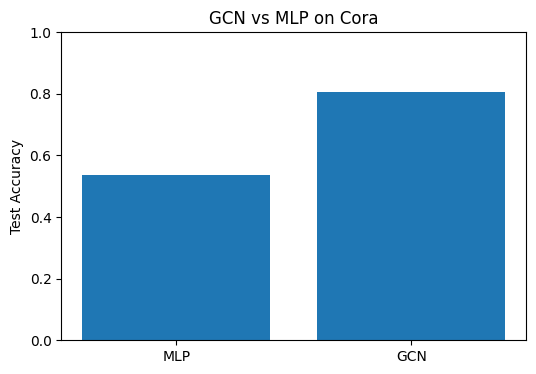

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Final test accuracy"])
plt.ylabel("Test Accuracy")
plt.title("GCN vs MLP on Cora")
plt.ylim(0, 1)
plt.show()

## Training curves

The next plot shows the test accuracy over training epochs for both models. This gives a more detailed view of how learning progressed.

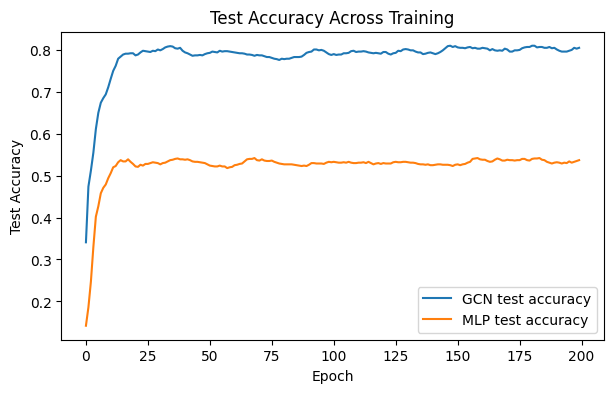

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(gcn_history["test_acc"], label="GCN test accuracy")
plt.plot(mlp_history["test_acc"], label="MLP test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Across Training")
plt.legend()
plt.show()

## Discussion

The GCN performed much better than the MLP baseline on this node classification task. Although both models reached a final training accuracy of 1.00, the GCN achieved a much higher validation accuracy (0.770 vs. 0.524) and test accuracy (0.805 vs. 0.537). This shows that the MLP was able to memorize the training nodes, but it did not generalize nearly as well as the GCN.

The training curves support this result. The GCN quickly improved during the first part of training and then stabilized around a test accuracy near 0.80, while the MLP leveled off much lower, around 0.53 to 0.54. This suggests that using graph structure provided important information that the feature-only baseline could not capture.

This outcome matches the core idea behind graph neural networks. In the Cora citation graph, linked papers often belong to related topics, so aggregating information from neighboring nodes helps the model make better predictions. Overall, the experiment shows that graph connectivity was highly useful for this task and was a major reason the GCN outperformed the MLP.

## Limitations and open challenges

One limitation of GNNs is oversmoothing. If too many graph convolution layers are stacked, node representations can become too similar to one another, which can hurt classification performance.

Another limitation is dependence on graph quality. If the graph has noisy, missing, or misleading edges, message passing can spread bad information and reduce model performance.

A broader challenge is scalability. Very large graphs can be harder to train on efficiently because neighborhood aggregation becomes more expensive as the graph grows.

## Follow-up experiment

A useful next experiment would be to test whether making the GCN deeper improves or hurts performance. For example, I would compare a 2-layer GCN against a 4-layer GCN on the same dataset to see whether deeper message passing helps capture more information or instead causes oversmoothing.